<a href="https://colab.research.google.com/github/Atharv26j13/2/blob/main/24a_20_7_26_Face_Recognition_Doland_Trump.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=37dbdf7215333ae501fa4af6738bf98b34e97f9efe58dff9f9177f1f2d9a1c11
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [2]:
from google.colab import files
files = files.upload()

Saving elon.jpg to elon.jpg
Saving jeffbezos.jpg to jeffbezos.jpg
Saving Donald Trump.jpg to Donald Trump.jpg


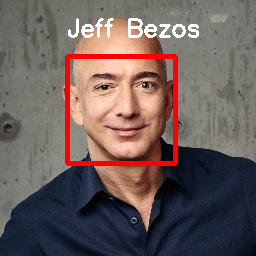

In [6]:
import face_recognition
import numpy as np
from google.colab.patches import cv2_imshow
import cv2

face_1 = face_recognition.load_image_file("elon.jpg")
face_1_encoding = face_recognition.face_encodings(face_1)[0]

face_2 = face_recognition.load_image_file("Donald Trump.jpg")
face_2_encoding = face_recognition.face_encodings(face_2)[0]

face_3 = face_recognition.load_image_file("jeffbezos.jpg")
face_3_encoding = face_recognition.face_encodings(face_3)[0]

known_face_encodings = [
    face_1_encoding,
    face_2_encoding,
    face_3_encoding
]

known_face_names = [
    "Elon Musk",
    "Donald Trump",
    "Jeff Bezos"
]

file_name = "jeffbezos.jpg"
unknown_image = face_recognition.load_image_file(file_name)
unknown_image_to_draw = cv2.imread(file_name)

face_locations = face_recognition.face_locations(unknown_image)
face_encodings = face_recognition.face_encodings(unknown_image, face_locations)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
    name = "Unknown"
    face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)
    best_match_index = np.argmin(face_distances)
    if matches[best_match_index]:
        name = known_face_names[best_match_index]
        cv2.rectangle(unknown_image_to_draw, (left, top), (right, bottom), (0, 0, 255),3)
        cv2.putText(unknown_image_to_draw, name, (left, top-20), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

cv2_imshow(unknown_image_to_draw)